# Week 5 – Clustering Analysis

**Student ID:** 249057766  
**Module:** MA7022 Data Mining and Neural Networks         
**Task 5:** Week 5 Computational Task – Clustering  

---

## Introduction

This notebook explores clustering techniques to discover patterns in the Online Retail dataset.  
Unlike supervised learning, clustering does not rely on labelled outcomes. Instead, the goal is to identify natural groupings within the data based on similarity between observations.

In this analysis, customers are used as the unit of analysis. Behavioural features such as total spending, number of transactions, and number of distinct products purchased are constructed and used to segment customers into groups using the K-means clustering algorithm.

The resulting clusters are then analysed and visualised using Principal Component Analysis (PCA) in order to better understand the structure present in the dataset.

## Task 1 — Decide the Unit of Analysis

In this analysis, customers are used as the unit of analysis.  
Clustering customers allows us to identify different purchasing behaviours within the dataset.

Customers may differ in terms of:
- how much they spend
- how frequently they purchase
- how many different products they buy

Identifying such behavioural groups can help reveal meaningful patterns in the retail dataset.

Customers were chosen because purchasing behaviour naturally varies across individuals, making them a meaningful unit for segmentation analysis.

## Task 2 — Feature Construction

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom


In [2]:
# clean the dataset
data = data.dropna(subset=["Customer ID"])
data = data[data["Quantity"] > 0]
data = data[data["Price"] > 0]

In [3]:
# create total price
data["TotalPrice"] = data["Quantity"] * data["Price"]

In [4]:
#aggregate by customer
customer_data = data.groupby("Customer ID").agg({
    "TotalPrice":"sum",
    "Invoice":"nunique",
    "StockCode":"nunique"
}).reset_index()

customer_data.columns = [
    "CustomerID",
    "TotalSpend",
    "NumTransactions",
    "NumProducts"
]

customer_data.head()

,CustomerID,TotalSpend,NumTransactions,NumProducts
0,12346.0,372.86,11,26
1,12347.0,1323.32,2,70
2,12348.0,222.16,1,20
3,12349.0,2671.14,3,90
4,12351.0,300.93,1,21


### Feature Construction

Three behavioural features were constructed for each customer.

TotalSpend – the total amount spent by a customer.        
NumTransactions – the number of invoices associated with the customer.        
NumProducts – the number of distinct products purchased.

Together, these variables capture different aspects of customer purchasing behaviour and provide a compact numerical representation suitable for clustering analysis.

## Task 3 — Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

features = customer_data[
    ["TotalSpend", "NumTransactions", "NumProducts"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

### Scaling

Clustering algorithms such as K-means rely on distance calculations between observations.

If features are on different scales, variables with larger values (such as total spending) would dominate the distance calculation.

To avoid this issue, the features were standardised using StandardScaler so that each variable has mean 0 and variance 1.

## Task 4 — Apply K-Means Clustering

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

customer_data["Cluster"] = kmeans.fit_predict(scaled_features)

customer_data.head()

,CustomerID,TotalSpend,NumTransactions,NumProducts,Cluster
0,12346.0,372.86,11,26,0
1,12347.0,1323.32,2,70,0
2,12348.0,222.16,1,20,0
3,12349.0,2671.14,3,90,0
4,12351.0,300.93,1,21,0


The number of clusters was set to 3 in order to obtain a simple segmentation of customer behaviour. 

A small number of clusters allows broad behavioural patterns to be identified while keeping the interpretation straightforward.

## Task 5 — Evaluate Clusters

In [7]:
# Cluster sizes
customer_data["Cluster"].value_counts()

Cluster
0    3840
1     467
2       5
Name: count, dtype: int64

In [8]:
# Cluster behaviour
customer_data.groupby("Cluster")[
    ["TotalSpend","NumTransactions","NumProducts"]
].mean()

,TotalSpend,NumTransactions,NumProducts
Cluster,,,
0,1065.770138,2.950000,43.352083
1,7840.958450,15.668094,221.828694
2,215543.670000,113.600000,875.200000


### Cluster Interpretation

Cluster 0 contains customers with relatively low spending and few transactions, suggesting occasional buyers.

Cluster 1 shows customers with moderate spending and a moderate number of transactions.

Cluster 2 contains high-spending customers with many transactions and a large variety of products purchased.

These clusters indicate distinct customer purchasing behaviours within the dataset.

### Cluster Balance
The clusters are not perfectly balanced. Cluster 0 contains the majority of customers, while Cluster 1 and Cluster 2 contain progressively smaller groups. 

This suggests that most customers exhibit relatively low or moderate purchasing behaviour, while a small number of customers represent high-value buyers.

## Task 6 — PCA Visualisation

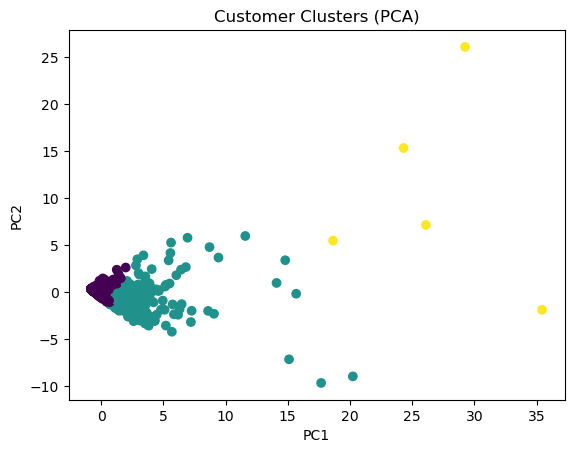

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

components = pca.fit_transform(scaled_features)

plt.scatter(
    components[:,0],
    components[:,1],
    c=customer_data["Cluster"]
)

plt.title("Customer Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Limitations

Clustering results depend on the selected features and the number of clusters chosen.

Different feature choices or clustering parameters may lead to different segmentations of the data.

The clustering results may also be sensitive to the chosen number of clusters (k). Different values of k could lead to different segmentations of the customers.
Additionally, K-means assumes spherical clusters and may not capture more complex cluster structures present in the dataset.

## Conclusion

This analysis applied clustering techniques to explore patterns in the Online Retail dataset. Customers were grouped based on their purchasing behaviour using features such as total spending, number of transactions, and number of products purchased.

The clustering results revealed distinct customer segments, including occasional buyers and high-value customers. Visualisation using PCA helped illustrate the structure of these clusters in a lower-dimensional space.

Overall, the analysis demonstrates how unsupervised learning methods such as K-means can be used to discover meaningful structure in transactional data.